In [4]:
from __future__ import annotations

import numpy.typing as npt
import torch

from cs336_basics.bpe_tokenizer import BpeTokenizer
from cs336_basics.LanguageModel import LanguageModel
from cs336_basics.AdamW import AdamW
from cs336_basics.utils import run_get_batch, run_get_lr_cosine_schedule, run_cross_entropy, run_gradient_clipping, run_save_checkpoint, run_load_checkpoint
 
import numpy as np
from cs336_basics.pretokenization_example import find_chunk_boundaries
import time
import json


In [6]:
import yaml
import torch

with open("reports/exp3/config.yaml", "r") as f:
    config = yaml.safe_load(f)

model_cfg = config["model"]
train_cfg = config["training"]
optim_cfg = config["optimizer"]
lr_cfg = config["lr_schedule"]



vocab_size = model_cfg["vocab_size"]
context_length = model_cfg["context_length"]
d_model = model_cfg["d_model"]
num_layers = model_cfg["num_layers"]
num_heads = model_cfg["num_heads"]
d_ff = model_cfg["d_ff"]
rope_theta = model_cfg["rope_theta"]


batch_size = train_cfg["batch_size"]
iterations = train_cfg["iterations"]
  

betas = tuple(optim_cfg["betas"])
weight_decay = optim_cfg["weight_decay"]
max_l2_norm = optim_cfg["max_l2_norm"]

max_lr = lr_cfg["max_lr"]
min_lr = lr_cfg["min_lr"]

warmup_iters = int(iterations * lr_cfg["warmup_ratio"])
cosine_cycle_iters = int(iterations * lr_cfg["cosine_cycle_ratio"])


In [7]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)
dtype = torch.bfloat16

In [8]:

# build train data from tokenizer
merges_filepath = 'output/TinyStoriesV2-GPT4-train-heap-merges.json'
vocab_filepath = 'output/TinyStoriesV2-GPT4-train-heap-vocab.json'

print('loading bpe tokenizer')
tokenizer = BpeTokenizer.from_files(vocab_filepath, merges_filepath, ['<|endoftext|>'])

loading bpe tokenizer


In [9]:
len(tokenizer.vocab_dict)

10000

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [11]:
print(vocab_size, context_length, d_model, num_layers, num_heads, d_ff, rope_theta, device, dtype)

10000 256 512 4 16 1344 10000 cuda torch.bfloat16


In [12]:
# lm = LanguageModel(vocab_size, context_length, d_model, num_layers, num_heads, d_ff, rope_theta, device=device, dtype=dtype)
# lm = lm.to(device)
# optimizer = AdamW(lm.parameters(), betas, weight_decay, lr=1e-3, eps=1e-8)


# create data

In [13]:

# input_path = "data/TinyStoriesV2-GPT4-train.txt"
# output_path = "data/train.bin"

# with open(input_path, "rb") as f, open(output_path, "wb") as out:
#     num_chunks = 40

#     boundaries = find_chunk_boundaries(
#         f,
#         num_chunks,
#         b"<|endoftext|>"
#     )

#     chunk = 1
#     for start, end in zip(boundaries[:-1], boundaries[1:]):
#         print(f'=== chunk {chunk} ===')
#         f.seek(start)

#         text = f.read(end - start).decode("utf-8")

#         token_ids = tokenizer.encode(text)

#         np.asarray(
#             token_ids,
#             dtype=np.uint16
#         ).tofile(out)
#         chunk += 1

In [14]:

# input_path = "data/TinyStoriesV2-GPT4-valid.txt"
# output_path = "data/valid.bin"

# with open(input_path, "rb") as f, open(output_path, "wb") as out:
#     num_chunks = 20

#     boundaries = find_chunk_boundaries(
#         f,
#         num_chunks,
#         b"<|endoftext|>"
#     )

#     chunk = 1
#     for start, end in zip(boundaries[:-1], boundaries[1:]):
#         print(f'=== chunk {chunk} ===')
#         f.seek(start)

#         text = f.read(end - start).decode("utf-8")

#         token_ids = tokenizer.encode(text)

#         np.asarray(
#             token_ids,
#             dtype=np.uint16
#         ).tofile(out)
#         chunk += 1

# train

In [15]:
losses = []

valid_data = np.memmap(
    "data/valid.bin",
    dtype=np.uint16,
    mode="r"
)

train_data = np.memmap(
    "data/train.bin",
    dtype=np.uint16,
    mode="r"
)

# val_data = np.load("valid.npy", mmap_mode="r")
logs = {
    "iteration": [],
    "tokens_processed": [],
    "train_loss": [],
    "val_loss": [],
    "val_iteration": [],
    "lr": [],
    "iter_time": [],
}

In [ ]:
def train_experiment(batch_size, iterations, max_lr, min_lr, warmup_iters, cosine_cycle_iters, seed):
    # val_data = np.load("valid.npy", mmap_mode="r")
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    print("batch_size", batch_size)
    print("iterations", iterations)
    
    lm = LanguageModel(vocab_size, context_length, d_model, num_layers, num_heads, d_ff, rope_theta, device=device, dtype=dtype)
    lm = lm.to(device)
    optimizer = AdamW(lm.parameters(), betas, weight_decay, lr=1e-3, eps=1e-8)

    logs = {
        "iteration": [],
        "tokens_processed": [],
        "train_loss": [],
        "val_loss": [],
        "val_iteration": [],
        "lr": [],
        "iter_time": [],
    }

    # lm model
    for it in range(1, iterations+1):

        # ===========
        # Train 
        # ===========
        lm.train()

        start_time = time.perf_counter()
        optimizer.zero_grad()

        indices, labels = run_get_batch(train_data, batch_size, context_length, device=device)
        output = lm.forward(indices, context_length)

        loss = run_cross_entropy(output, labels)
        if (it) % 100 == 0:
            print(f'========= itr {it} =========')
            print(loss.item())

        loss.backward()

        lr = run_get_lr_cosine_schedule(it, max_lr, min_lr, warmup_iters, cosine_cycle_iters)
        for group in optimizer.param_groups:
            group["lr"] = lr

        run_gradient_clipping(lm.parameters(), max_l2_norm)
        optimizer.step()

        iter_time = time.perf_counter() - start_time
        tokens_processed = (it) * batch_size * context_length

        logs["iteration"].append(it)
        logs["tokens_processed"].append(tokens_processed)
        logs["train_loss"].append(loss.item())
        logs["lr"].append(lr)
        logs["iter_time"].append(iter_time)    

        # ===========
        # Valid 
        # ===========
        if (it) % 100 == 0:

            lm.eval()

            valid_losses = []

            with torch.no_grad():
                for _ in range(100):

                    indices, labels = run_get_batch(
                        valid_data,
                        batch_size,
                        context_length,
                        device=device
                    )

                    output = lm.forward(
                        indices,
                        context_length
                    )

                    val_loss = run_cross_entropy(
                        output,
                        labels
                    )

                    valid_losses.append(
                        val_loss.item()
                    )

            mean_val_loss = (
                torch.tensor(valid_losses)
                .mean()
                .item()
            )

            logs["val_iteration"].append(it)
            logs["val_loss"].append(mean_val_loss)

            print(
                f"itr {it} | "
                f"train {loss.item():.4f} | "
                f"val {mean_val_loss:.4f}"
            )
        # if it >= 2000:
        #     break
    #     if (it) % 2000 == 0:
    #         run_save_checkpoint(lm, optimizer, it, f'checkpoints/{it}_iteration')

    with open(f"reports/exp3/batch_{batch_size}_train_logs.json", "w") as f:
        json.dump(logs, f)
    # run_save_checkpoint(lm, optimizer, it, 'checkpoints/final')

In [22]:

warmup_iters = int(iterations * lr_cfg["warmup_ratio"])
cosine_cycle_iters = int(iterations * lr_cfg["cosine_cycle_ratio"])

batch_list = [16, 32, 64]
iterations_list = [4000, 2000, 1000]

In [23]:
for i in range(len(batch_list)):
    warmup_iters = int(iterations * lr_cfg["warmup_ratio"])
    cosine_cycle_iters = int(iterations * lr_cfg["cosine_cycle_ratio"])
    logs = train_experiment(
        batch_size=batch_list[i],
        iterations=iterations_list[i],
        max_lr=1e-3,
        min_lr=1.0e-6,
        warmup_iters=warmup_iters,
        cosine_cycle_iters=cosine_cycle_iters,
        seed=42,
    )

batch_size 16
iterations 4000
========= itr 100 =========
8.125
itr 100 | train 8.1250 | val 8.1356
========= itr 200 =========
5.09375
itr 200 | train 5.0938 | val 5.1584
========= itr 300 =========
4.125
itr 300 | train 4.1250 | val 4.1870
========= itr 400 =========
3.6875
itr 400 | train 3.6875 | val 3.7453
========= itr 500 =========
3.34375
itr 500 | train 3.3438 | val 3.4981
========= itr 600 =========
3.328125
itr 600 | train 3.3281 | val 3.3052
========= itr 700 =========
3.265625
itr 700 | train 3.2656 | val 3.1334
========= itr 800 =========
2.859375
itr 800 | train 2.8594 | val 2.9928
========= itr 900 =========
3.0625
itr 900 | train 3.0625 | val 2.8941
========= itr 1000 =========
2.9375
itr 1000 | train 2.9375 | val 2.7945
========= itr 1100 =========
2.5625
itr 1100 | train 2.5625 | val 2.7491
========= itr 1200 =========
2.828125
itr 1200 | train 2.8281 | val 2.6592
========= itr 1300 =========
2.671875
itr 1300 | train 2.6719 | val 2.6267
========= itr 1400 =========


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

max_lrs = [5e-4, 1e-3, 2e-3]
window = 100

plt.figure(figsize=(10, 6))

for max_lr in max_lrs:
    log_path = f"reports/exp2/lr_{max_lr}_train_logs.json"

    with open(log_path, "r") as f:
        logs = json.load(f)

    losses = np.array(logs["train_loss"])
    iterations = np.array(logs["iteration"])

    # 100-step mean
    n = len(losses) // window

    mean_loss = (
        losses[:n * window]
        .reshape(n, window)
        .mean(axis=1)
    )

    mean_iteration = (
        iterations[:n * window]
        .reshape(n, window)
        .mean(axis=1)
    )

    plt.plot(
        mean_iteration,
        mean_loss,
        label=f"LR={max_lr:g}"
    )

plt.xlabel("Iteration")
plt.ylabel("Cross Entropy Loss")
plt.title("Max Learning Rate Sweep")
plt.legend()
plt.grid()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'reports/exp3/batch_16_train_logs.json'

<Figure size 1000x600 with 0 Axes>

0.0005
1.8997656106948853
0.001
1.7414844036102295
0.002
1.841796875


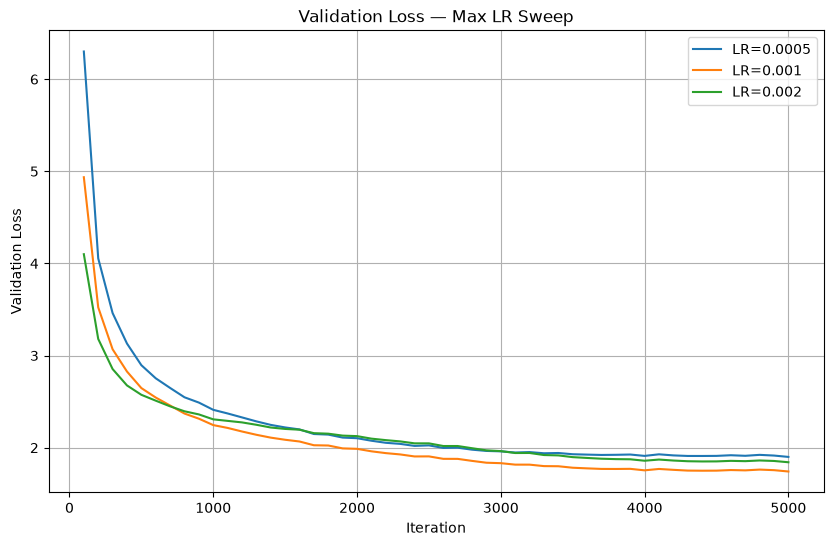

In [3]:
plt.figure(figsize=(10, 6))

for max_lr in max_lrs:
    log_path = f"reports/exp2/lr_{max_lr}_train_logs.json"

    with open(log_path, "r") as f:
        logs = json.load(f)

    plt.plot(
        logs["val_iteration"],
        logs["val_loss"],
        label=f"LR={max_lr:g}"
    )
    print(max_lr)
    print(logs["val_loss"][-1])

plt.xlabel("Iteration")
plt.ylabel("Validation Loss")
plt.title("Validation Loss — Max LR Sweep")
plt.legend()
plt.grid()
plt.show()

# single lr train plot

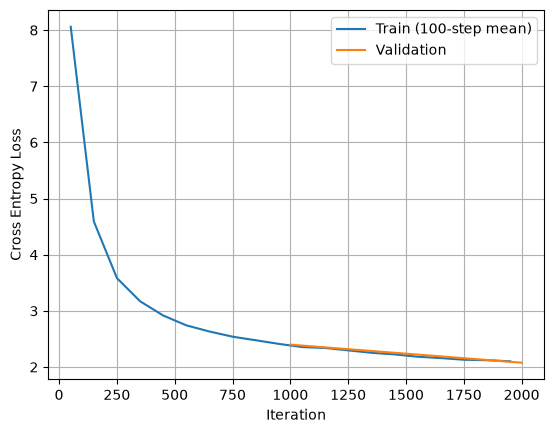

In [54]:
import numpy as np
import matplotlib.pyplot as plt

window = 100

losses = np.array(logs["train_loss"])
iterations = np.array(logs["iteration"])

n = len(losses) // window

mean_loss = losses[:n * window].reshape(n, window).mean(axis=1)
mean_iteration = iterations[:n * window].reshape(n, window).mean(axis=1)

plt.figure()
plt.plot(mean_iteration, mean_loss, label="Train (100-step mean)")

plt.plot(logs['val_iteration'], logs['val_loss'], label="Validation")

plt.xlabel("Iteration")
plt.ylabel("Cross Entropy Loss")
plt.legend()
plt.grid()
plt.show()

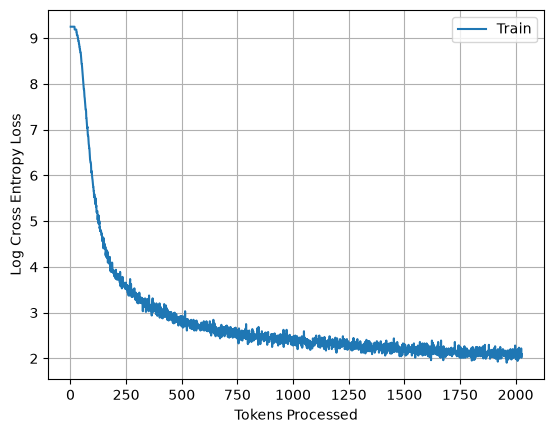

In [55]:
import matplotlib.pyplot as plt

# 1. Loss curve
plt.figure()
plt.plot(logs["iteration"], logs["train_loss"], label="Train")

# 如果 val_loss 不是每个 iteration 都记录，
# 最好单独记录 val_iteration / val_tokens_processed
# plt.plot(logs["tokens_processed"], logs["val_loss"], label="Validation")

plt.xlabel("Tokens Processed")
plt.ylabel("Log Cross Entropy Loss")
plt.legend()
plt.grid()
plt.show()

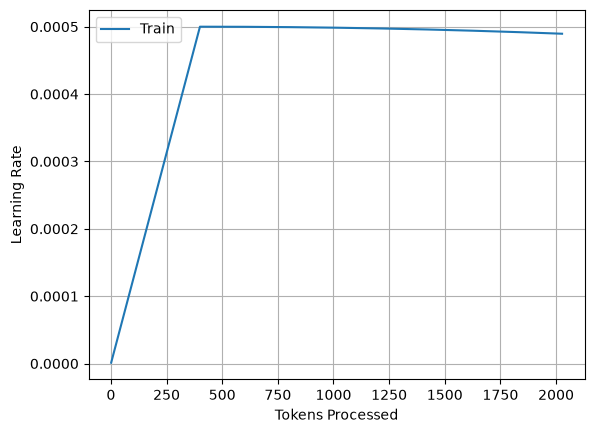

In [53]:
import matplotlib.pyplot as plt

# 1. Loss curve
plt.figure()
plt.plot(logs["iteration"], logs["lr"], label="Train")

# 如果 val_loss 不是每个 iteration 都记录，
# 最好单独记录 val_iteration / val_tokens_processed
# plt.plot(logs["tokens_processed"], logs["val_loss"], label="Validation")

plt.xlabel("Tokens Processed")
plt.ylabel("Learning Rate")
plt.legend()
plt.grid()
plt.show()

# After Train

In [33]:

print('loading model')
run_load_checkpoint('checkpoints/75000_iteration', lm, optimizer)

loading model


FileNotFoundError: [Errno 2] No such file or directory: 'checkpoints/75000_iteration'

In [12]:

valid_data = np.memmap(
    "data/valid.bin",
    dtype=np.uint16,
    mode="r"
)

train_data = np.memmap(
    "data/train.bin",
    dtype=np.uint16,
    mode="r"
)

In [14]:
def get_checkpoint_loss(data, checkpoint_filepath, lm, optimizer):
    run_load_checkpoint(checkpoint_filepath, lm, optimizer)

    np.random.seed(42)

    
    lm.eval()
    valid_losses = []
    with torch.no_grad():
        
        for i in range(100):
            optimizer.zero_grad()
            indices, labels = run_get_batch(data, batch_size, context_length, device=device)
            output = lm.forward(indices, context_length)

            loss = run_cross_entropy(output, labels)
            valid_losses.append(loss.item())

    valid_loss = torch.tensor(valid_losses).mean()
    return valid_loss

In [15]:
x_axis = [10000, 20000, 25000, 30000, 35000, 40000, 45000, 50000, 55000, 60000, 65000, 70000, 75000]
valid_losses = []
train_losses = []
for itr in x_axis:
    checkpoint_file = f'checkpoints/{itr}_iteration'
    mean_valid_loss = get_checkpoint_loss(valid_data, checkpoint_file, lm, optimizer)
    mean_train_loss = get_checkpoint_loss(train_data, checkpoint_file, lm, optimizer)
    valid_losses.append(mean_valid_loss)
    train_losses.append(mean_train_loss)

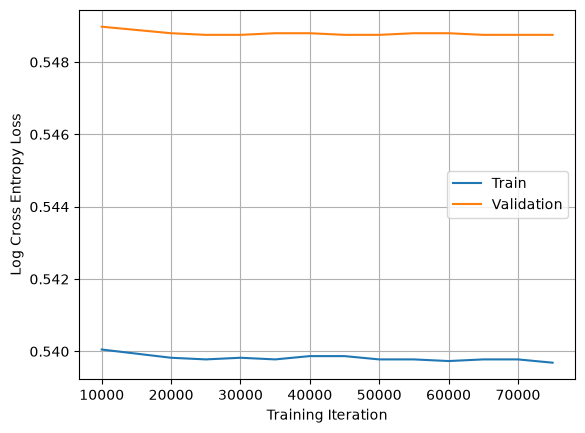

In [16]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure()

plt.plot(
    x_axis,
    np.log(train_losses),
    label="Train"
)

plt.plot(
    x_axis,
    np.log(valid_losses),
    label="Validation"
)

plt.xlabel("Training Iteration")
plt.ylabel("Log Cross Entropy Loss")
plt.legend()
plt.grid()
plt.show()

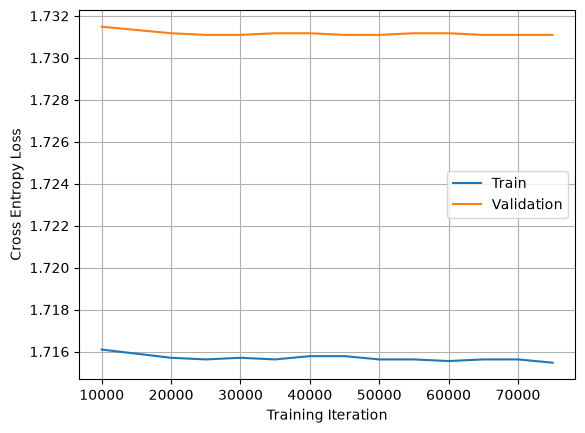

In [17]:

plt.figure()

plt.plot(
    x_axis,
    train_losses,
    label="Train"
)

plt.plot(
    x_axis,
    valid_losses,
    label="Validation"
)

plt.xlabel("Training Iteration")
plt.ylabel("Cross Entropy Loss")
plt.legend()
plt.grid()
plt.show()